# Electric Vehicle Range Prediction

**Goal:** Build a regression model that predicts EV driving range (`Range_km`) from real-world driving and environmental conditions — speed, acceleration, battery state, terrain (slope), traffic, weather, and vehicle characteristics — then prepare the results for a Power BI dashboard.

**Dataset:** `EV_Range_Prediction_Carefully_Engineered_10000.csv` — 10,000 simulated driving-trip records (half original "Kaggle_Source_Row" entries, half "Synthetic_Augmented_Row" entries used to expand the dataset).

**Workflow:**
1. Preprocess Data
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Build & Evaluate ML Models
5. Export data for Power BI


## 1. Preprocess Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

df = pd.read_csv('EV_Range_Prediction_Carefully_Engineered_10000.csv')
print("Shape:", df.shape)
df.head()


Shape: (10000, 22)


,Vehicle_ID,Timestamp,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Driving_Mode,Road_Type,Traffic_Condition,Slope_%,Weather_Condition,Temperature_C,Humidity_%,Wind_Speed_ms,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Energy_Consumption_kWh,Battery_Capacity_kWh,Range_km,Data_Origin
0,1102.0,2024-01-01 00:00:00,111.507366,-2.773816,30.415148,378.091525,25.314786,2.0,1.0,1.0,6.879446,4.0,0.741770,42.172533,7.829253,31.112020,1822.967368,20.757508,12.054317,72.97,81.58,Kaggle_Source_Row
1,1435.0,2024-01-01 00:01:00,48.612323,-0.796982,97.385534,392.718377,18.240755,1.0,2.0,1.0,-3.007212,4.0,-3.495516,57.018427,4.495572,31.504366,2091.831914,0.642918,4.488701,79.82,427.52,Kaggle_Source_Row
2,1860.0,2024-01-01 00:02:00,108.733320,0.253800,84.912600,398.993495,44.449145,1.0,1.0,3.0,0.029585,1.0,9.248275,69.028911,5.144489,33.838015,1816.702497,40.842824,11.701377,75.53,232.51,Kaggle_Source_Row
3,1270.0,2024-01-01 00:03:00,38.579484,-2.111395,28.777904,358.128273,28.980155,1.0,2.0,2.0,8.271943,3.0,2.868409,86.638349,4.518283,33.256014,1283.102642,5.305229,7.389266,43.97,47.16,Kaggle_Source_Row
4,1106.0,2024-01-01 00:04:00,57.172438,1.477883,29.740160,310.888162,33.184551,2.0,1.0,1.0,2.776814,2.0,16.750244,27.189185,4.263406,33.579678,2160.350788,5.825926,6.761205,77.13,93.18,Kaggle_Source_Row


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              10000 non-null  float64
 1   Timestamp               10000 non-null  str    
 2   Speed_kmh               10000 non-null  float64
 3   Acceleration_ms2        10000 non-null  float64
 4   Battery_State_%         10000 non-null  float64
 5   Battery_Voltage_V       10000 non-null  float64
 6   Battery_Temperature_C   10000 non-null  float64
 7   Driving_Mode            10000 non-null  float64
 8   Road_Type               10000 non-null  float64
 9   Traffic_Condition       10000 non-null  float64
 10  Slope_%                 10000 non-null  float64
 11  Weather_Condition       10000 non-null  float64
 12  Temperature_C           10000 non-null  float64
 13  Humidity_%              10000 non-null  float64
 14  Wind_Speed_ms           10000 non-null  float64
 1

### 1.1 Missing values

No nulls are reported by `isnull()`, but that doesn't mean the data is clean — a few columns contain physically impossible values (e.g. negative distance travelled) that behave like *hidden* missing/bad data. We check for both.

In [3]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing cells")
df.isnull().sum()[df.isnull().sum() > 0]


Missing values per column:
0 total missing cells


Series([], dtype: int64)

In [4]:
# Physically impossible values act like disguised missing data
print("Negative Distance_Travelled_km rows:", (df['Distance_Travelled_km'] < 0).sum())
print("Negative Range_km rows:", (df['Range_km'] < 0).sum())
print("Negative Battery_Capacity_kWh rows:", (df['Battery_Capacity_kWh'] < 0).sum())

# A handful of rows have a tiny negative distance (sensor noise around 0), e.g. -0.58km.
# Clip these to 0 rather than dropping the rows, since every other field is valid.
df['Distance_Travelled_km'] = df['Distance_Travelled_km'].clip(lower=0)


Negative Distance_Travelled_km rows: 7
Negative Range_km rows: 0
Negative Battery_Capacity_kWh rows: 0


### 1.2 Duplicates

In [5]:
dupe_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dupe_count}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)


Exact duplicate rows: 0
Shape after de-duplication: (10000, 22)


### 1.3 Recover the categorical columns

`Driving_Mode`, `Road_Type`, `Traffic_Condition`, and `Weather_Condition` are stored as floats (e.g. `2.0119`, `0.9976`) instead of clean integers — a side effect of the synthetic augmentation step adding small noise. We round them back to their original integer codes and map those codes to readable labels.

> **Note:** No data dictionary was provided with this file, so the label names below (Eco/Normal/Sport, City/Highway/Rural, etc.) are a reasonable, clearly-documented interpretation of the numeric codes — not values that were confirmed from metadata. The numeric codes themselves are exact (rounded from noisy floats back to 1/2/3/4).

In [6]:
categorical_code_cols = ['Driving_Mode', 'Road_Type', 'Traffic_Condition', 'Weather_Condition']
for c in categorical_code_cols:
    df[c] = df[c].round().astype(int)

driving_mode_map = {1: 'Eco', 2: 'Normal', 3: 'Sport'}
road_type_map    = {1: 'City', 2: 'Highway', 3: 'Rural'}
traffic_map      = {1: 'Low', 2: 'Medium', 3: 'High'}
weather_map      = {1: 'Clear', 2: 'Cloudy', 3: 'Rainy', 4: 'Snowy'}

df['Driving_Mode_Label']       = df['Driving_Mode'].map(driving_mode_map)
df['Road_Type_Label']          = df['Road_Type'].map(road_type_map)
df['Traffic_Condition_Label']  = df['Traffic_Condition'].map(traffic_map)
df['Weather_Condition_Label']  = df['Weather_Condition'].map(weather_map)

df[['Driving_Mode_Label', 'Road_Type_Label', 'Traffic_Condition_Label', 'Weather_Condition_Label']].apply(lambda s: s.value_counts())


,Driving_Mode_Label,Road_Type_Label,Traffic_Condition_Label,Weather_Condition_Label
City,NaN,3260.0,NaN,NaN
Clear,NaN,NaN,NaN,2521.0
Cloudy,NaN,NaN,NaN,2518.0
Eco,3273.0,NaN,NaN,NaN
High,NaN,NaN,3349.0,NaN
Highway,NaN,3470.0,NaN,NaN
Low,NaN,NaN,3213.0,NaN
Medium,NaN,NaN,3438.0,NaN
Normal,3470.0,NaN,NaN,NaN
Rainy,NaN,NaN,NaN,2501.0


### 1.4 Parse timestamp & drop non-predictive ID columns

In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

# Vehicle_ID is an arbitrary identifier, not a predictive feature
# Data_Origin only tells us how the row was generated, not a real-world driving condition
id_cols_to_drop = ['Vehicle_ID', 'Timestamp']
df.drop(columns=id_cols_to_drop, inplace=True)
df.head()


,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Driving_Mode,Road_Type,Traffic_Condition,Slope_%,Weather_Condition,Temperature_C,Humidity_%,Wind_Speed_ms,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Energy_Consumption_kWh,Battery_Capacity_kWh,Range_km,Data_Origin,Driving_Mode_Label,Road_Type_Label,Traffic_Condition_Label,Weather_Condition_Label,Hour,DayOfWeek
0,111.507366,-2.773816,30.415148,378.091525,25.314786,2,1,1,6.879446,4,0.741770,42.172533,7.829253,31.112020,1822.967368,20.757508,12.054317,72.97,81.58,Kaggle_Source_Row,Normal,City,Low,Snowy,0,0
1,48.612323,-0.796982,97.385534,392.718377,18.240755,1,2,1,-3.007212,4,-3.495516,57.018427,4.495572,31.504366,2091.831914,0.642918,4.488701,79.82,427.52,Kaggle_Source_Row,Eco,Highway,Low,Snowy,0,0
2,108.733320,0.253800,84.912600,398.993495,44.449145,1,1,3,0.029585,1,9.248275,69.028911,5.144489,33.838015,1816.702497,40.842824,11.701377,75.53,232.51,Kaggle_Source_Row,Eco,City,High,Clear,0,0
3,38.579484,-2.111395,28.777904,358.128273,28.980155,1,2,2,8.271943,3,2.868409,86.638349,4.518283,33.256014,1283.102642,5.305229,7.389266,43.97,47.16,Kaggle_Source_Row,Eco,Highway,Medium,Rainy,0,0
4,57.172438,1.477883,29.740160,310.888162,33.184551,2,1,1,2.776814,2,16.750244,27.189185,4.263406,33.579678,2160.350788,5.825926,6.761205,77.13,93.18,Kaggle_Source_Row,Normal,City,Low,Cloudy,0,0


### 1.5 Outlier detection & handling

We use the IQR method on the key continuous features and cap (winsorize) rather than delete, so we don't throw away real trips just because they're extreme.

In [8]:
continuous_cols = ['Speed_kmh', 'Acceleration_ms2', 'Battery_Voltage_V', 'Battery_Temperature_C',
                   'Slope_%', 'Temperature_C', 'Humidity_%', 'Wind_Speed_ms', 'Tire_Pressure_psi',
                   'Vehicle_Weight_kg', 'Distance_Travelled_km', 'Energy_Consumption_kWh',
                   'Battery_Capacity_kWh', 'Range_km']

def outlier_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_summary = {}
for c in continuous_cols:
    low, high = outlier_bounds(df[c])
    n_out = ((df[c] < low) | (df[c] > high)).sum()
    outlier_summary[c] = n_out
    df[c] = df[c].clip(lower=low, upper=high)

pd.Series(outlier_summary, name='outliers_capped').sort_values(ascending=False)


Range_km                  81
Speed_kmh                  0
Battery_Voltage_V          0
Battery_Temperature_C      0
Slope_%                    0
Acceleration_ms2           0
Temperature_C              0
Humidity_%                 0
Tire_Pressure_psi          0
Wind_Speed_ms              0
Vehicle_Weight_kg          0
Distance_Travelled_km      0
Energy_Consumption_kWh     0
Battery_Capacity_kWh       0
Name: outliers_capped, dtype: int64

## 2. Exploratory Data Analysis (EDA)

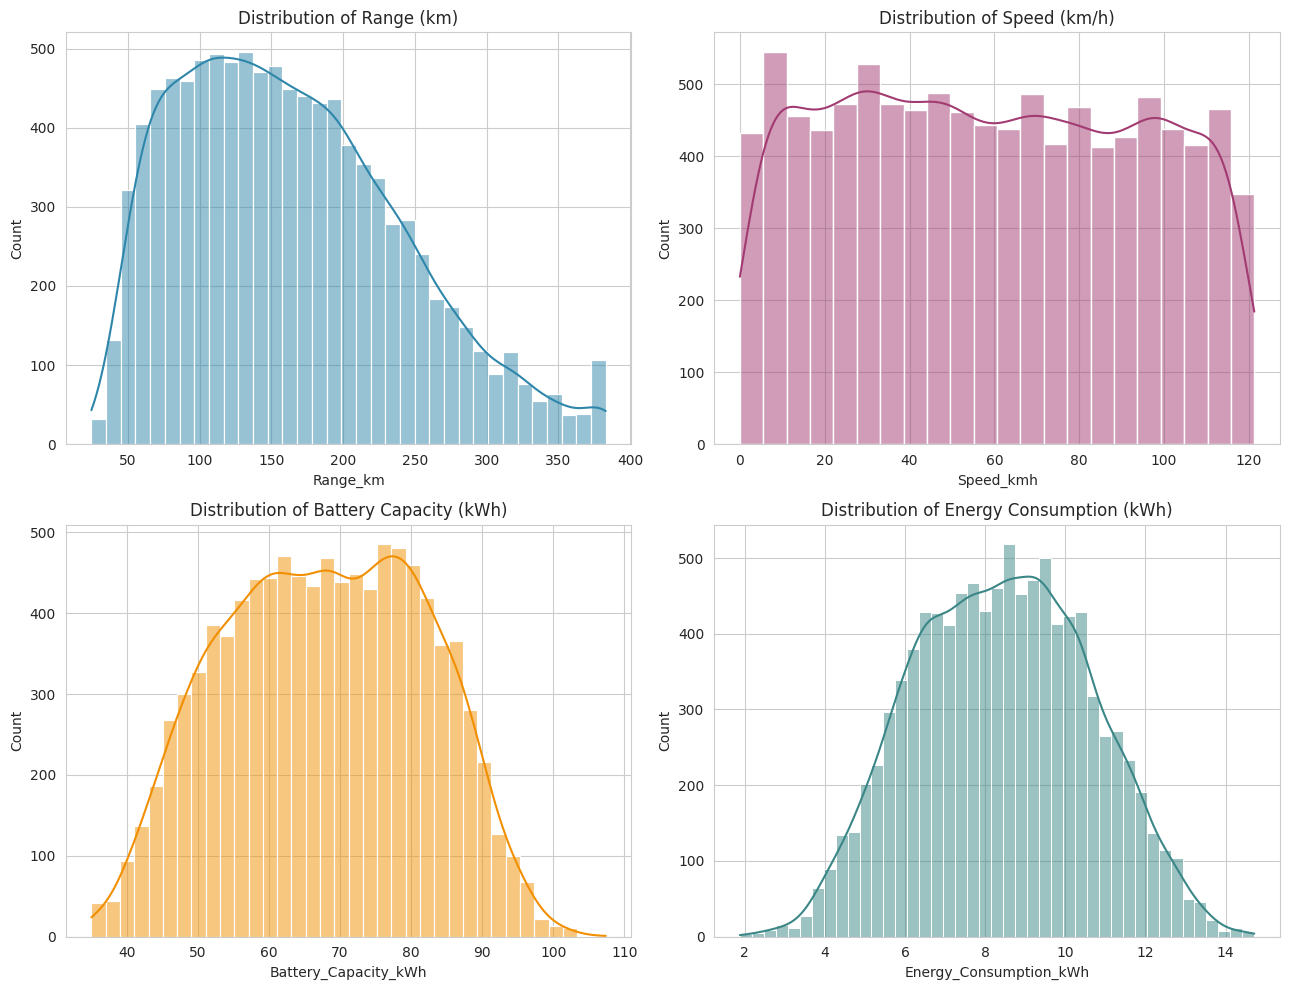

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
sns.histplot(df['Range_km'], kde=True, ax=axes[0,0], color='#2E86AB').set_title('Distribution of Range (km)')
sns.histplot(df['Speed_kmh'], kde=True, ax=axes[0,1], color='#A23B72').set_title('Distribution of Speed (km/h)')
sns.histplot(df['Battery_Capacity_kWh'], kde=True, ax=axes[1,0], color='#F18F01').set_title('Distribution of Battery Capacity (kWh)')
sns.histplot(df['Energy_Consumption_kWh'], kde=True, ax=axes[1,1], color='#3B8686').set_title('Distribution of Energy Consumption (kWh)')
plt.tight_layout()
plt.savefig('eda_histograms.png', dpi=110)
plt.show()


/tmp/ipykernel_626/2148156672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Range_km', ax=ax, palette='Set2')
/tmp/ipykernel_626/2148156672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Range_km', ax=ax, palette='Set2')


/tmp/ipykernel_626/2148156672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Range_km', ax=ax, palette='Set2')
/tmp/ipykernel_626/2148156672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Range_km', ax=ax, palette='Set2')


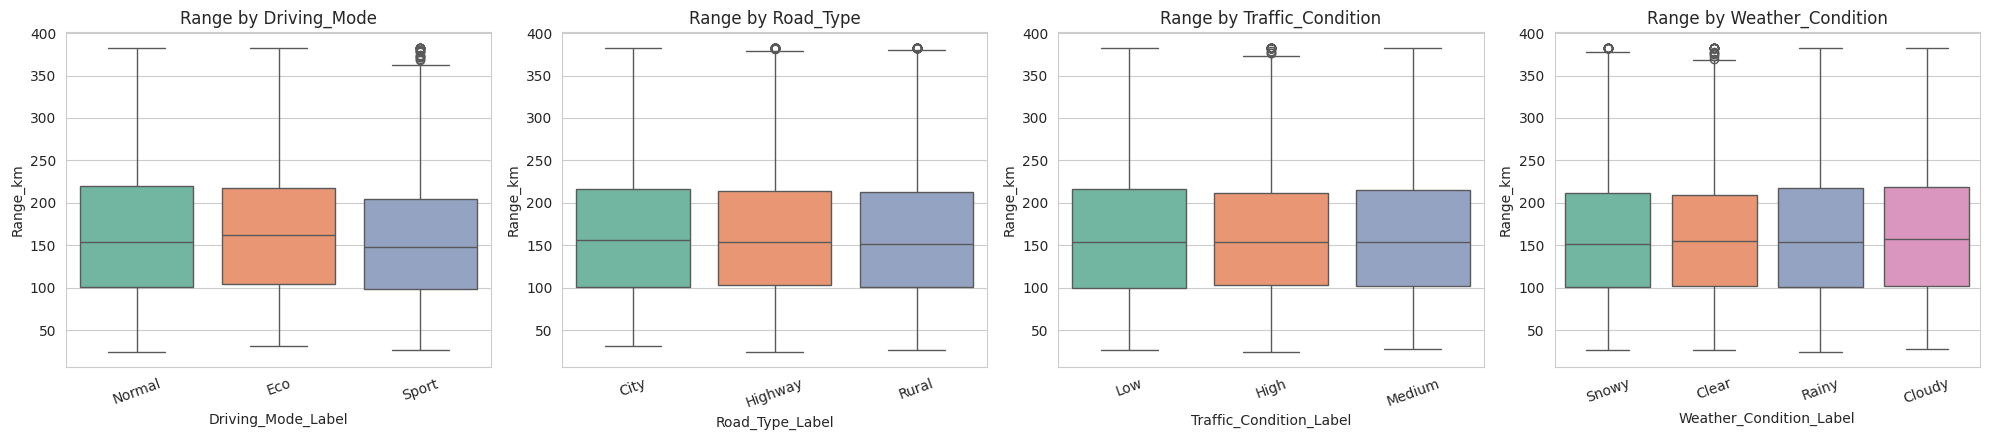

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col in zip(axes, ['Driving_Mode_Label', 'Road_Type_Label', 'Traffic_Condition_Label', 'Weather_Condition_Label']):
    sns.boxplot(data=df, x=col, y='Range_km', ax=ax, palette='Set2')
    ax.set_title(f'Range by {col.replace("_Label","")}')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('eda_categorical_boxplots.png', dpi=110)
plt.show()


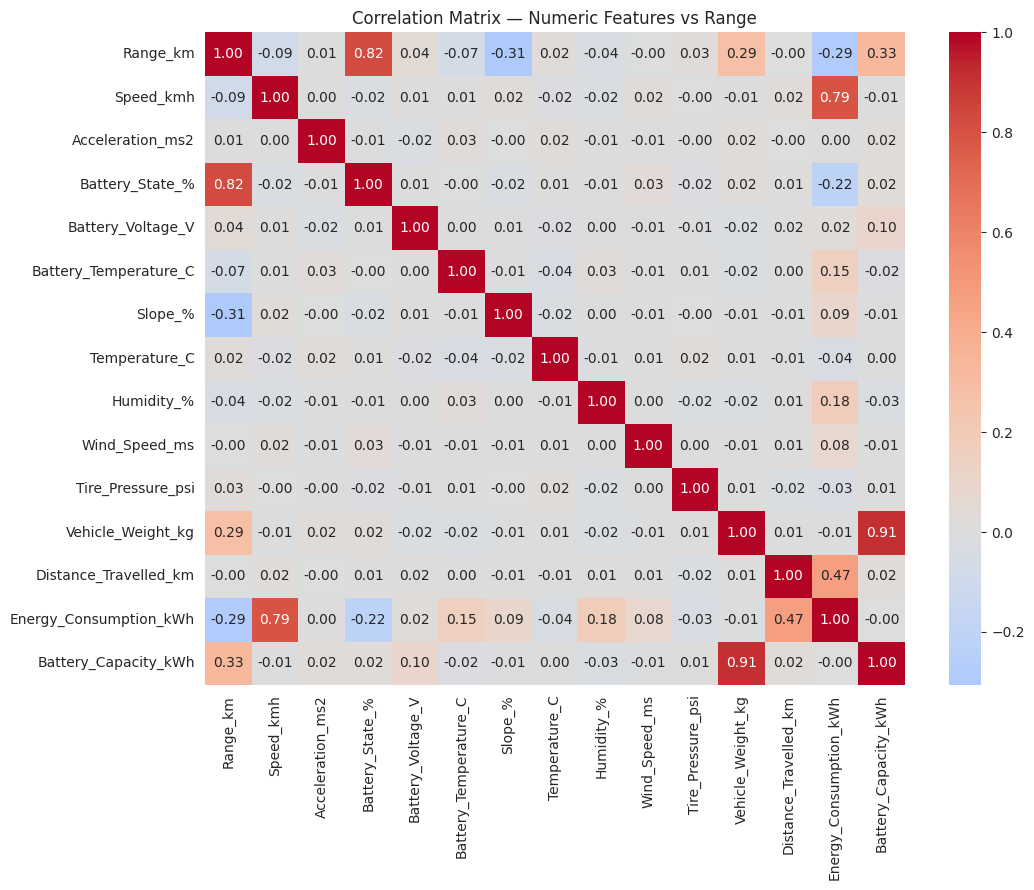

Range_km                  1.000000
Battery_State_%           0.822973
Battery_Capacity_kWh      0.334897
Vehicle_Weight_kg         0.286132
Battery_Voltage_V         0.042853
Tire_Pressure_psi         0.025297
Temperature_C             0.019175
Acceleration_ms2          0.005819
Wind_Speed_ms            -0.001294
Distance_Travelled_km    -0.004854
Humidity_%               -0.035405
Battery_Temperature_C    -0.072388
Speed_kmh                -0.091970
Energy_Consumption_kWh   -0.290511
Slope_%                  -0.306434
Name: Range_km, dtype: float64

In [11]:
numeric_for_corr = ['Range_km', 'Speed_kmh', 'Acceleration_ms2', 'Battery_State_%', 'Battery_Voltage_V',
                    'Battery_Temperature_C', 'Slope_%', 'Temperature_C', 'Humidity_%', 'Wind_Speed_ms',
                    'Tire_Pressure_psi', 'Vehicle_Weight_kg', 'Distance_Travelled_km',
                    'Energy_Consumption_kWh', 'Battery_Capacity_kWh']

plt.figure(figsize=(11, 9))
corr = df[numeric_for_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Features vs Range')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=110)
plt.show()

corr['Range_km'].sort_values(ascending=False)


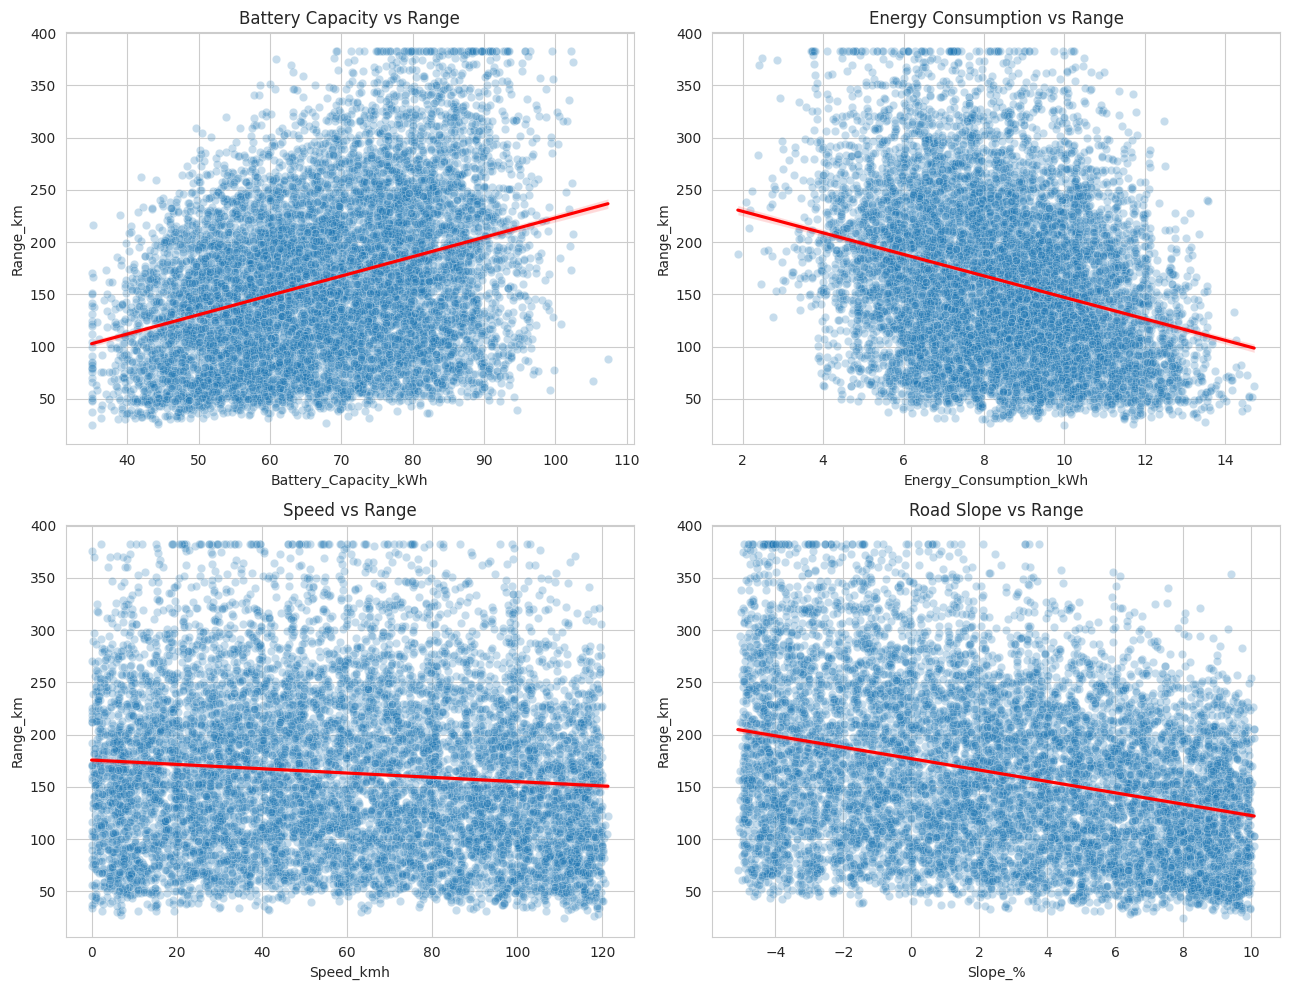

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
sns.scatterplot(data=df, x='Battery_Capacity_kWh', y='Range_km', alpha=0.25, ax=axes[0,0])
sns.regplot(data=df, x='Battery_Capacity_kWh', y='Range_km', scatter=False, color='red', ax=axes[0,0])
axes[0,0].set_title('Battery Capacity vs Range')

sns.scatterplot(data=df, x='Energy_Consumption_kWh', y='Range_km', alpha=0.25, ax=axes[0,1])
sns.regplot(data=df, x='Energy_Consumption_kWh', y='Range_km', scatter=False, color='red', ax=axes[0,1])
axes[0,1].set_title('Energy Consumption vs Range')

sns.scatterplot(data=df, x='Speed_kmh', y='Range_km', alpha=0.25, ax=axes[1,0])
sns.regplot(data=df, x='Speed_kmh', y='Range_km', scatter=False, color='red', ax=axes[1,0])
axes[1,0].set_title('Speed vs Range')

sns.scatterplot(data=df, x='Slope_%', y='Range_km', alpha=0.25, ax=axes[1,1])
sns.regplot(data=df, x='Slope_%', y='Range_km', scatter=False, color='red', ax=axes[1,1])
axes[1,1].set_title('Road Slope vs Range')

plt.tight_layout()
plt.savefig('eda_scatterplots.png', dpi=110)
plt.show()


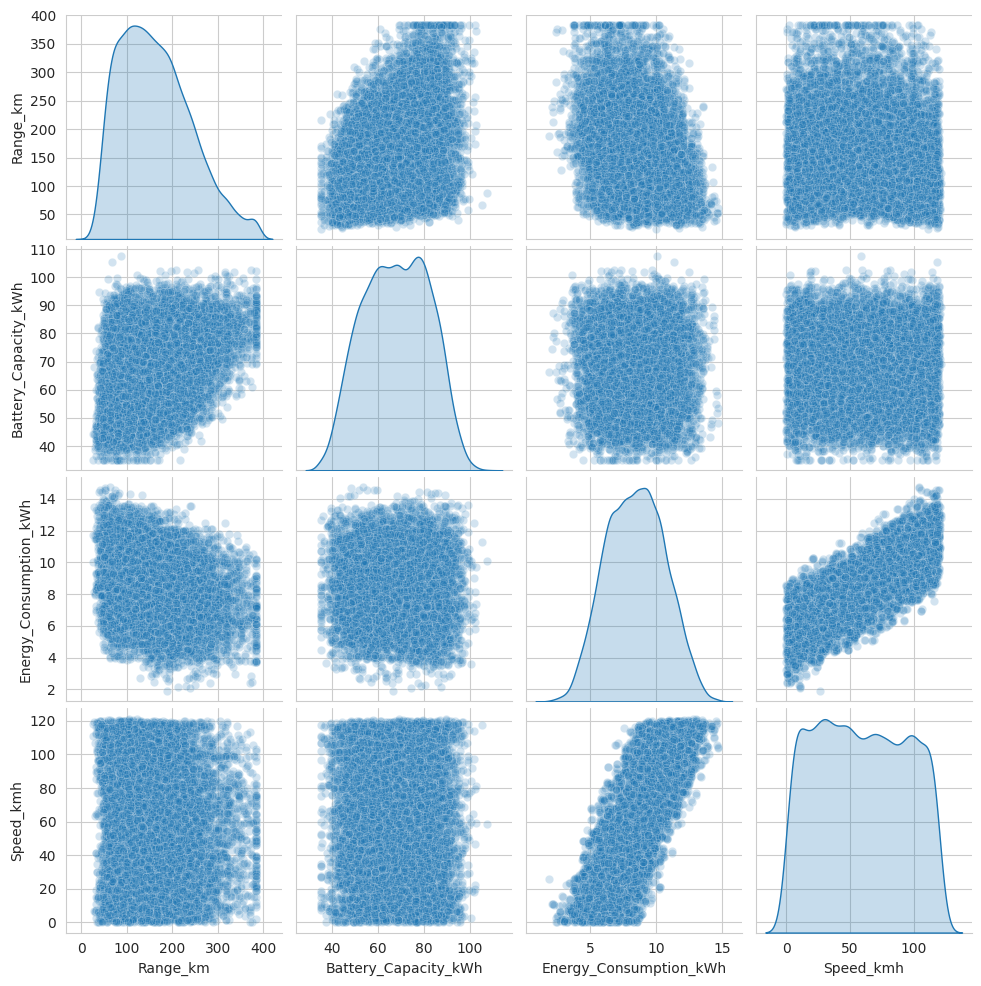

In [13]:
pairplot_vars = ['Range_km', 'Battery_Capacity_kWh', 'Energy_Consumption_kWh', 'Speed_kmh']
sns.pairplot(df[pairplot_vars], diag_kind='kde', plot_kws={'alpha':0.2})
plt.savefig('eda_pairplot.png', dpi=110)
plt.show()


**EDA takeaways:** `Battery_Capacity_kWh` and `Energy_Consumption_kWh` show the strongest linear relationships with `Range_km`. Speed and slope have weaker, non-linear relationships with range, which motivates trying tree-based models in addition to linear regression.

## 3. Feature Engineering

In [14]:
# Efficiency & battery-usage ratios — these are the mechanistic drivers of range in a real EV
df['Efficiency_kWh_per_km']   = df['Energy_Consumption_kWh'] / df['Distance_Travelled_km'].replace(0, np.nan)
df['Efficiency_kWh_per_km']   = df['Efficiency_kWh_per_km'].fillna(df['Efficiency_kWh_per_km'].median())
df['Battery_Usage_Ratio']     = df['Energy_Consumption_kWh'] / df['Battery_Capacity_kWh']
df['Usable_Battery_kWh']      = df['Battery_Capacity_kWh'] * (df['Battery_State_%'] / 100)
df['Weight_per_kWh']          = df['Vehicle_Weight_kg'] / df['Battery_Capacity_kWh']

# Driving-behavior interaction terms
df['Speed_x_Slope']           = df['Speed_kmh'] * df['Slope_%']
df['Abs_Slope']               = df['Slope_%'].abs()
df['Aggressive_Accel']        = df['Acceleration_ms2'].abs()

# Environmental stress on the battery (cold and very hot temps both hurt range)
df['Temp_Deviation_From_20C'] = (df['Temperature_C'] - 20).abs()
df['Battery_Temp_Deviation']  = (df['Battery_Temperature_C'] - 25).abs()

# Cyclical encoding of hour-of-day (captures rush hour without a false ordinal jump at midnight)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df[['Efficiency_kWh_per_km', 'Battery_Usage_Ratio', 'Usable_Battery_kWh', 'Weight_per_kWh',
    'Speed_x_Slope', 'Abs_Slope', 'Aggressive_Accel', 'Temp_Deviation_From_20C']].describe()


,Efficiency_kWh_per_km,Battery_Usage_Ratio,Usable_Battery_kWh,Weight_per_kWh,Speed_x_Slope,Abs_Slope,Aggressive_Accel,Temp_Deviation_From_20C
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.551755,0.130121,41.097549,27.549535,149.100392,4.195061,1.475329,11.440539
std,59.405843,0.045784,18.324867,2.549826,313.677607,2.775810,0.866404,6.681676
min,0.085782,0.024701,8.394939,19.661295,-571.276548,0.000442,0.000214,0.003050
25%,0.246647,0.097865,26.002831,25.807363,-39.448460,1.850589,0.702278,5.910574
50%,0.342357,0.123903,39.076015,27.370404,82.823582,3.795937,1.466016,11.240589
75%,0.584359,0.156311,54.322099,29.102838,314.359358,6.325697,2.221873,16.803491
max,5887.990906,0.360737,98.907585,41.614588,1169.470868,10.079735,3.064718,25.355675


### 3.1 Encode categorical variables

One-hot encode the four road/environment categories and the `Data_Origin` flag; drop the noisy numeric code columns now that we have clean labels and dummies.

In [15]:
df_model = df.drop(columns=['Driving_Mode', 'Road_Type', 'Traffic_Condition', 'Weather_Condition'])

categorical_cols = ['Driving_Mode_Label', 'Road_Type_Label', 'Traffic_Condition_Label',
                    'Weather_Condition_Label', 'Data_Origin']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_model.shape)
df_model.head()


Shape after encoding: (10000, 38)


,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Slope_%,Temperature_C,Humidity_%,Wind_Speed_ms,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Energy_Consumption_kWh,Battery_Capacity_kWh,Range_km,Hour,DayOfWeek,Efficiency_kWh_per_km,Battery_Usage_Ratio,Usable_Battery_kWh,Weight_per_kWh,Speed_x_Slope,Abs_Slope,Aggressive_Accel,Temp_Deviation_From_20C,Battery_Temp_Deviation,Hour_sin,Hour_cos,Driving_Mode_Label_Normal,Driving_Mode_Label_Sport,Road_Type_Label_Highway,Road_Type_Label_Rural,Traffic_Condition_Label_Low,Traffic_Condition_Label_Medium,Weather_Condition_Label_Cloudy,Weather_Condition_Label_Rainy,Weather_Condition_Label_Snowy,Data_Origin_Synthetic_Augmented_Row
0,111.507366,-2.773816,30.415148,378.091525,25.314786,6.879446,0.741770,42.172533,7.829253,31.112020,1822.967368,20.757508,12.054317,72.97,81.58,0,0,0.580721,0.165196,22.193933,24.982422,767.108875,6.879446,2.773816,19.258230,0.314786,0.0,1.0,True,False,False,False,True,False,False,False,True,False
1,48.612323,-0.796982,97.385534,392.718377,18.240755,-3.007212,-3.495516,57.018427,4.495572,31.504366,2091.831914,0.642918,4.488701,79.82,382.98,0,0,6.981767,0.056235,77.733133,26.206864,-146.187578,3.007212,0.796982,23.495516,6.759245,0.0,1.0,False,False,True,False,True,False,False,False,True,False
2,108.733320,0.253800,84.912600,398.993495,44.449145,0.029585,9.248275,69.028911,5.144489,33.838015,1816.702497,40.842824,11.701377,75.53,232.51,0,0,0.286498,0.154924,64.134487,24.052727,3.216824,0.029585,0.253800,10.751725,19.449145,0.0,1.0,False,False,False,False,False,False,False,False,False,False
3,38.579484,-2.111395,28.777904,358.128273,28.980155,8.271943,2.868409,86.638349,4.518283,33.256014,1283.102642,5.305229,7.389266,43.97,47.16,0,0,1.392827,0.168052,12.653644,29.181320,319.127296,8.271943,2.111395,17.131591,3.980155,0.0,1.0,False,False,True,False,False,True,False,True,False,False
4,57.172438,1.477883,29.740160,310.888162,33.184551,2.776814,16.750244,27.189185,4.263406,33.579678,2160.350788,5.825926,6.761205,77.13,93.18,0,0,1.160537,0.087660,22.938585,28.009215,158.757252,2.776814,1.477883,3.249756,8.184551,0.0,1.0,True,False,False,False,True,False,True,False,False,False


### 3.2 Dimensionality reduction check (PCA)

Several environmental columns (temperature, humidity, wind) are moderately correlated. We run PCA purely as a diagnostic to see how much variance a handful of components would capture — useful context even if we keep the original interpretable features for the final model.

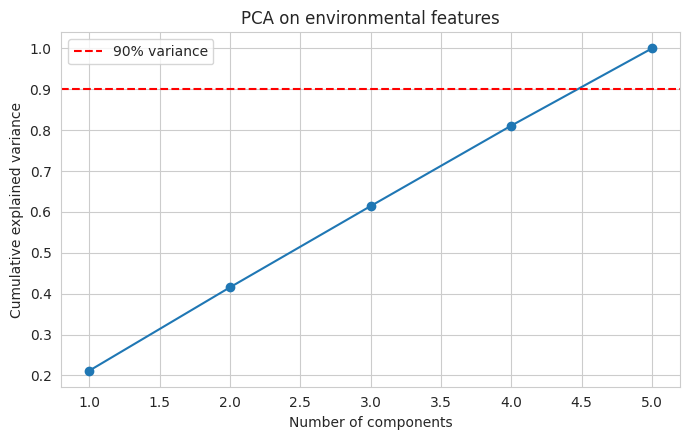

Explained variance by component: [0.212 0.204 0.199 0.197 0.189]


In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

env_cols = ['Temperature_C', 'Humidity_%', 'Wind_Speed_ms', 'Battery_Temperature_C', 'Slope_%']
env_scaled = StandardScaler().fit_transform(df_model[env_cols])

pca = PCA().fit(env_scaled)
explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7,4.5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.axhline(0.9, color='red', linestyle='--', label='90% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA on environmental features')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=110)
plt.show()
print("Explained variance by component:", np.round(pca.explained_variance_ratio_, 3))


These environmental features don't compress well (need ~4 of 5 components for 90% variance) — meaning they carry largely independent information, so we keep them as separate features rather than replacing them with principal components.

## 4. Build & Evaluate ML Models

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X = df_model.drop(columns=['Range_km'])
y = df_model['Range_km']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train shape: (8000, 37)  Test shape: (2000, 37)


In [18]:
def evaluate(name, y_true, y_pred, store):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    store[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"{name:22s}  R2={r2:.4f}   RMSE={rmse:7.2f} km   MAE={mae:7.2f} km")

results = {}

# 1. Linear Regression (baseline, needs scaled features)
lin = LinearRegression().fit(X_train_scaled, y_train)
evaluate('Linear Regression', y_test, lin.predict(X_test_scaled), results)

# 2. Ridge Regression (regularized linear baseline)
ridge = Ridge(alpha=5.0).fit(X_train_scaled, y_train)
evaluate('Ridge Regression', y_test, ridge.predict(X_test_scaled), results)

# 3. Random Forest (tree-based, no scaling needed)
rf = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=2,
                            random_state=42, n_jobs=-1).fit(X_train, y_train)
evaluate('Random Forest', y_test, rf.predict(X_test), results)

# 4. Gradient Boosting (tree-based, sequential boosting)
gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3,
                                 random_state=42).fit(X_train, y_train)
evaluate('Gradient Boosting', y_test, gbr.predict(X_test), results)


Linear Regression       R2=0.9036   RMSE=  24.35 km   MAE=  18.46 km
Ridge Regression        R2=0.9037   RMSE=  24.34 km   MAE=  18.45 km


Random Forest           R2=0.9294   RMSE=  20.83 km   MAE=  15.15 km


Gradient Boosting       R2=0.9428   RMSE=  18.75 km   MAE=  13.70 km


### 4.1 Why not Logistic Regression?

The task brief lists Logistic Regression as an example algorithm, but Logistic Regression is a **classification** method — it predicts a category or probability, not a continuous number like kilometers. Since `Range_km` is continuous, it calls for **regression** algorithms (which is what we used above).

To still make direct use of a Logistic Regression model, we bin `Range_km` into three practical categories (Low / Medium / High range) and treat that as a separate classification problem — useful if a driver just wants a quick "how far can I roughly go" bucket rather than an exact number.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

range_bins = [0, 100, 250, np.inf]
range_labels = ['Low (<100km)', 'Medium (100-250km)', 'High (>250km)']
y_class = pd.cut(y, bins=range_bins, labels=range_labels)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

logreg = LogisticRegression(max_iter=1000).fit(Xc_train_scaled, yc_train)
yc_pred = logreg.predict(Xc_test_scaled)

print("Logistic Regression accuracy:", round(accuracy_score(yc_test, yc_pred), 4))
print()
print(classification_report(yc_test, yc_pred))


Logistic Regression accuracy: 0.89



                    precision    recall  f1-score   support

     High (>250km)       0.81      0.75      0.78       289
      Low (<100km)       0.91      0.89      0.90       484
Medium (100-250km)       0.90      0.92      0.91      1227

          accuracy                           0.89      2000
         macro avg       0.87      0.85      0.86      2000
      weighted avg       0.89      0.89      0.89      2000



### 4.2 Compare regression models

                         R2       RMSE        MAE
Gradient Boosting  0.942823  18.752248  13.700259
Random Forest      0.929431  20.832862  15.148406
Ridge Regression   0.903670  24.340114  18.452074
Linear Regression  0.903619  24.346523  18.456805


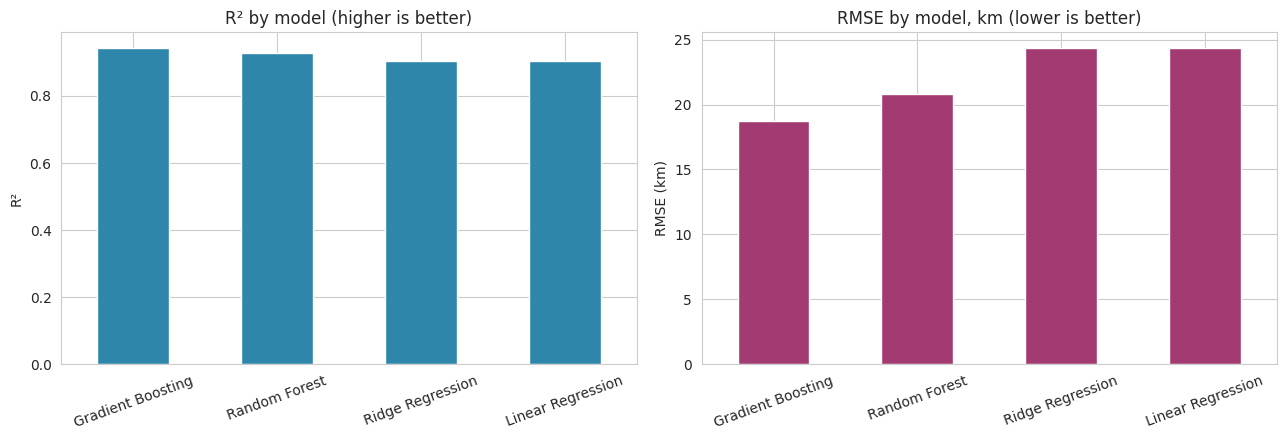

In [20]:
results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(results_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
results_df['R2'].plot(kind='bar', ax=axes[0], color='#2E86AB')
axes[0].set_title('R² by model (higher is better)')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=20)

results_df['RMSE'].plot(kind='bar', ax=axes[1], color='#A23B72')
axes[1].set_title('RMSE by model, km (lower is better)')
axes[1].set_ylabel('RMSE (km)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=110)
plt.show()


In [21]:
best_model_name = results_df['R2'].idxmax()
print("Best model by R2:", best_model_name)

best_model = {'Linear Regression': lin, 'Ridge Regression': ridge,
              'Random Forest': rf, 'Gradient Boosting': gbr}[best_model_name]
best_X_test = X_test_scaled if best_model_name in ['Linear Regression', 'Ridge Regression'] else X_test
best_preds = best_model.predict(best_X_test)


Best model by R2: Gradient Boosting


### 4.3 Feature importance (best tree-based model)

/tmp/ipykernel_626/3730167496.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


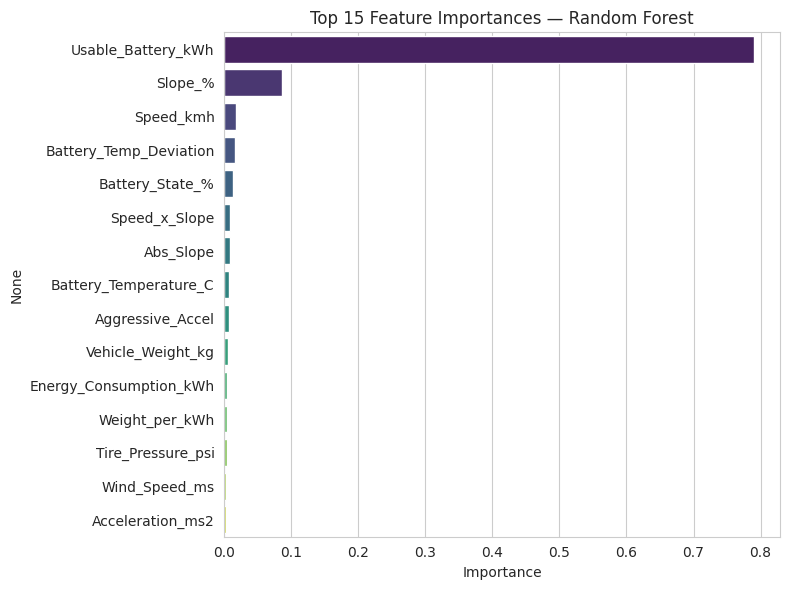

Usable_Battery_kWh        0.789571
Slope_%                   0.085600
Speed_kmh                 0.017660
Battery_Temp_Deviation    0.016501
Battery_State_%           0.013152
Speed_x_Slope             0.009013
Abs_Slope                 0.008106
Battery_Temperature_C     0.006631
Aggressive_Accel          0.006343
Vehicle_Weight_kg         0.005259
Energy_Consumption_kWh    0.004256
Weight_per_kWh            0.003665
Tire_Pressure_psi         0.003247
Wind_Speed_ms             0.003006
Acceleration_ms2          0.002924
dtype: float64

In [22]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=110)
plt.show()

importances


### 4.4 Residual analysis (best model)

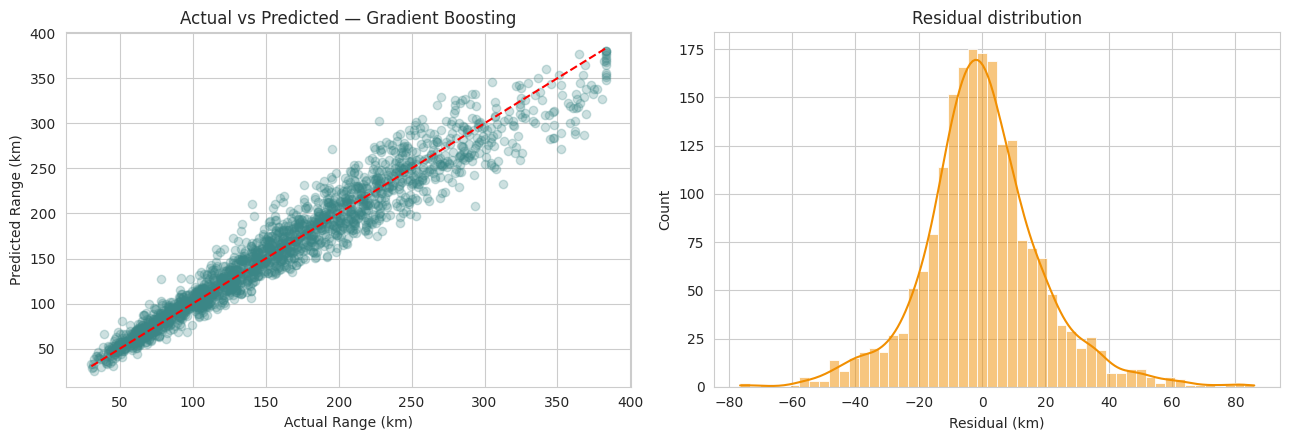

Residual mean: 0.034  Residual std: 18.752


In [23]:
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y_test, best_preds, alpha=0.25, color='#3B8686')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Range (km)')
axes[0].set_ylabel('Predicted Range (km)')
axes[0].set_title(f'Actual vs Predicted — {best_model_name}')

sns.histplot(residuals, kde=True, ax=axes[1], color='#F18F01')
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual (km)')

plt.tight_layout()
plt.savefig('residuals.png', dpi=110)
plt.show()

print("Residual mean:", round(residuals.mean(), 3), " Residual std:", round(residuals.std(), 3))


## 5. Export Data for Power BI

We export three files that a Power BI dashboard can load directly:

1. **`powerbi_ev_data.csv`** — the full cleaned + engineered dataset (one row per trip), for building distribution charts, slicers by driving mode/road type/weather, etc.
2. **`powerbi_model_predictions.csv`** — the test-set actual vs. predicted range for every model, so you can chart predicted-vs-actual and error by model.
3. **`powerbi_feature_importance.csv`** — feature importances, for a bar chart of what drives range the most.

In [24]:
# 1) Full cleaned + engineered dataset
df.to_csv('powerbi_ev_data.csv', index=False)

# 2) Actual vs predicted for every model on the same test rows
predictions_export = pd.DataFrame({
    'Actual_Range_km': y_test.values,
    'Pred_LinearRegression': lin.predict(X_test_scaled),
    'Pred_RidgeRegression': ridge.predict(X_test_scaled),
    'Pred_RandomForest': rf.predict(X_test),
    'Pred_GradientBoosting': gbr.predict(X_test),
})
predictions_export['Best_Model'] = best_model_name
for col in predictions_export.columns:
    if col.startswith('Pred_'):
        predictions_export[col.replace('Pred_', 'Error_')] = predictions_export['Actual_Range_km'] - predictions_export[col]
predictions_export.to_csv('powerbi_model_predictions.csv', index=False)

# 3) Model comparison metrics + feature importance
results_df.reset_index().rename(columns={'index': 'Model'}).to_csv('powerbi_model_metrics.csv', index=False)
importances.reset_index().rename(columns={'index': 'Feature', 0: 'Importance'}).to_csv('powerbi_feature_importance.csv', index=False)

print("Exported files:")
for f in ['powerbi_ev_data.csv', 'powerbi_model_predictions.csv', 'powerbi_model_metrics.csv', 'powerbi_feature_importance.csv']:
    print(" -", f)


Exported files:
 - powerbi_ev_data.csv
 - powerbi_model_predictions.csv
 - powerbi_model_metrics.csv
 - powerbi_feature_importance.csv


## 6. Building the Power BI Dashboard

Load the four exported CSVs into Power BI (`Get Data > Text/CSV`) and build:

**Page 1 — Range Overview**
- Histogram/distribution of `Range_km` (`powerbi_ev_data.csv`) — use a Power BI histogram visual or binned bar chart
- Card visuals: Average Range, Min Range, Max Range
- Box plot or clustered column of Range by `Driving_Mode_Label`, `Road_Type_Label`, `Weather_Condition_Label`

**Page 2 — Key Influencing Variables**
- Bar chart from `powerbi_feature_importance.csv` (Feature vs Importance)
- Scatter chart: `Battery_Capacity_kWh` vs `Range_km`, colored by `Driving_Mode_Label`
- Scatter chart: `Energy_Consumption_kWh` vs `Range_km`
- Correlation-style matrix visual (Power BI's built-in "Key influencers" visual works well pointed at `Range_km`)

**Page 3 — Model Comparison & Predictions**
- Clustered bar chart from `powerbi_model_metrics.csv` (Model vs R2, and a second chart for RMSE)
- Scatter chart from `powerbi_model_predictions.csv`: `Actual_Range_km` vs each `Pred_*` column, with a diagonal reference line to visually judge fit
- Histogram of the `Error_*` columns to show prediction error spread per model
- Slicer on `Best_Model` / model selector for the person viewing the dashboard to switch predicted-vs-actual series

This gives drivers a way to explore how conditions affect range, and gives manufacturers a side-by-side view of model accuracy and the top engineering levers (battery capacity, energy consumption, slope, weather) that move range the most.